# Week 4 Day 2 Lab


### Problem 1: Random Data Set
1. Generate a data set of size 300 using `np.random`
2. Save this data set as a pandas dataframe
3. Download the dataset as a csv using `dataframe_name.to_csv("file_name.csv", index=False)`

In [1]:
import numpy as np
import pandas as pd
from google.colab import files

data = np.random.randint(0, 100, 300)

df = pd.DataFrame({"Data": data})

df.to_csv("random_data.csv", index=False)

files.download("random_data.csv")

print(df.head())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Data
0    77
1    45
2    98
3     0
4    91


### Problem 2: Measures of Centrality
There are many ways to calculate what a data set is centered around. A few examples you have seen:

- Mean - The average of a dataset ($\bar{x}=\frac{1}{n}\sum\limits_{i=1}^nx_i$ for data points $x_i$)
- Median - The "middle data point" (average of 2 middle data points if data size is even-sized)
- Mode - The most common value (value with most number of occurences in data set)


1. Write your own function that calculate each of these.
2. Read the csv from Problem 1 into your notebook using `pd.read_csv("file_name.csv")`
3. Plot a histogram of the data and use `plt.axvline()` to plot vertical lines for the mean, median, and mode on the same histogram.
4. Do you notice anything about the mean, median, and mode? How can you explain this behavior?

In [2]:
x = [100,201,303,405,503]
np.mean(x)

np.float64(302.4)

Mean: 48.29333333333334
Median: 48.0
Mode: 91


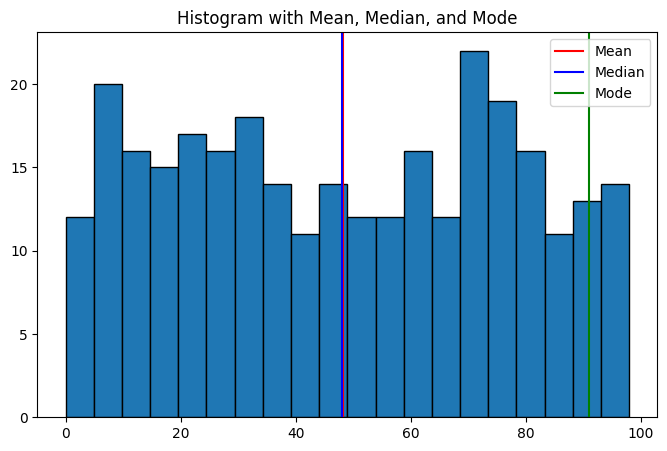

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("random_data.csv")
x = df["Data"]

def my_mean(x):
    return sum(x) / len(x)
def my_median(x):
    s = sorted(x)
    n = len(s)
    if n % 2 == 0:
        return (s[n//2-1] + s[n//2]) / 2
    else:
        return s[n//2]
def my_mode(x):
    counts = {}
    for i in x:
        counts[i] = counts.get(i, 0) + 1
    return max(counts, key=counts.get)

mean = my_mean(list(x))
median = my_median(list(x))
mode = my_mode(list(x))

print("Mean:", mean)
print("Median:", median)
print("Mode:", mode)

plt.figure(figsize=(8,5))
plt.hist(x, bins=20, edgecolor="black")

plt.axvline(mean, color="red", label="Mean")
plt.axvline(median, color="blue", label="Median")
plt.axvline(mode, color="green", label="Mode")

plt.title("Histogram with Mean, Median, and Mode")
plt.legend()
plt.show()

In [5]:
#4 The mean, median, and mode are similar, but they are not exactly the same because the data were generated randomly. I think the small differences are caused by the randomness of the data.

### Problem 3: Measures of Variability
We don't care solely where the data is centered, but also how spread out the data is around that center. Some ways we can measure this:
- Mean Absolute Deviation - Average of distance to the mean ($MAD(x)= \frac{1}{n}\sum\limits_{i=1}^n|x_i-\bar{x}|$)
- Variance - Average squared distance to the mean ($Var(x)=\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2$)
- Standard Deviation - Square root of average squared distance to the mean ($s(x)=\sqrt{\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2}$)

where $x$ is the entire dataset, $x_i$ is a data point, and $\bar{x}$ is the mean of the dataset.

1. Write your own function that calculate each of these.
2. Plot a histogram of the data and use `plt.axvline(mean + variance)` and `plt.axvline(mean-variance)` to plot vertical lines for variance on the same histogram. Do the same with adding and subtracting mean absolute deviation and standard deviation.
3. Do you notice anything about lines corresponding to the different definitions variability? How can you explain this behavior?

Mean: 48.29333333333334
MAD: 24.8992
Variance: 810.8339555555555
Standard Deviation: 28.475146278036142


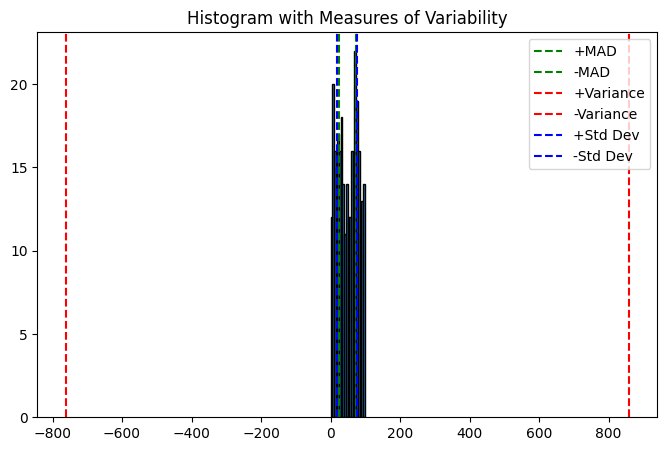

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = df["Data"]
mean = np.mean(x)

def mad(x):
    return np.mean(np.abs(x - np.mean(x)))
def variance(x):
    return np.mean((x - np.mean(x))**2)
def std(x):
    return np.sqrt(variance(x))

MAD = mad(x)
VAR = variance(x)
STD = std(x)

print("Mean:", mean)
print("MAD:", MAD)
print("Variance:", VAR)
print("Standard Deviation:", STD)

plt.figure(figsize=(8,5))
plt.hist(x, bins=20, edgecolor="black")

plt.axvline(mean + MAD, color="green", linestyle="--", label="+MAD")
plt.axvline(mean - MAD, color="green", linestyle="--", label="-MAD")

plt.axvline(mean + VAR, color="red", linestyle="--", label="+Variance")
plt.axvline(mean - VAR, color="red", linestyle="--", label="-Variance")

plt.axvline(mean + STD, color="blue", linestyle="--", label="+Std Dev")
plt.axvline(mean - STD, color="blue", linestyle="--", label="-Std Dev")

plt.title("Histogram with Measures of Variability")
plt.legend()
plt.show()

In [11]:
#3 The standard deviation and the mean absolute deviation are closer to the mean than the variance. This is because the variance uses squared values. The standard deviation uses the same units as the original data, so it is easier to understand.